/var/folders/jy/pc_qtmgx7vg538t3wpxxq4n00000gn/T/ipykernel_46499/1987753161.py:21: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")


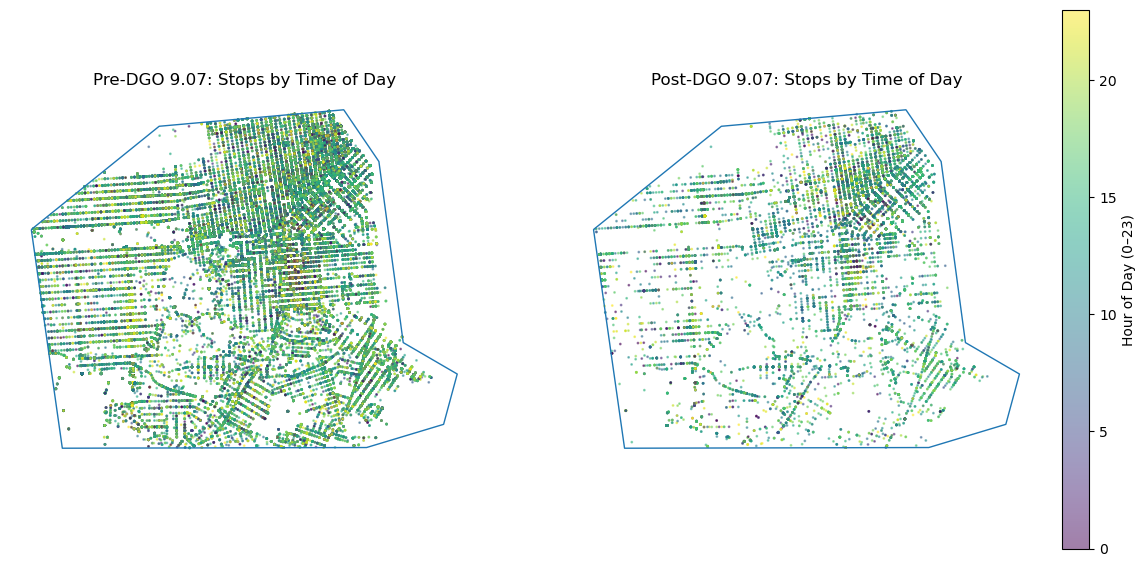

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

df["stop_datetime"] = pd.to_datetime(df["stop_datetime"], errors="coerce")
df["hour"] = df["stop_datetime"].dt.hour
df = df.dropna(subset=["longitude", "latitude", "hour", "post_DGO"])


gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)
sf = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_20m.zip"
)
sf = sf[sf["GEOID"] == "06075"]
gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")
gdf_pre  = gdf[gdf["post_DGO"] == 0]
gdf_post = gdf[gdf["post_DGO"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sf.boundary.plot(ax=axes[0], linewidth=1)
sc0 = axes[0].scatter(
    gdf_pre.geometry.x,
    gdf_pre.geometry.y,
    c=gdf_pre["hour"],
    s=1,
    alpha=0.5,
    vmin=0,
    vmax=23
)
axes[0].set_title("Pre-DGO 9.07: Stops by Time of Day")
axes[0].set_axis_off()

# Post
sf.boundary.plot(ax=axes[1], linewidth=1)
sc1 = axes[1].scatter(
    gdf_post.geometry.x,
    gdf_post.geometry.y,
    c=gdf_post["hour"],
    s=1,
    alpha=0.5,
    vmin=0,
    vmax=23
)
axes[1].set_title("Post-DGO 9.07: Stops by Time of Day")
axes[1].set_axis_off()

cbar = fig.colorbar(sc1, ax=axes, fraction=0.03, pad=0.02)
cbar.set_label("Hour of Day (0–23)")
# Save figure
plt.savefig(
    "/Users/thisisjasmine/Desktop/ECO225/dgo907_pre_post_time_map.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


/var/folders/jy/pc_qtmgx7vg538t3wpxxq4n00000gn/T/ipykernel_46499/768689461.py:14: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")


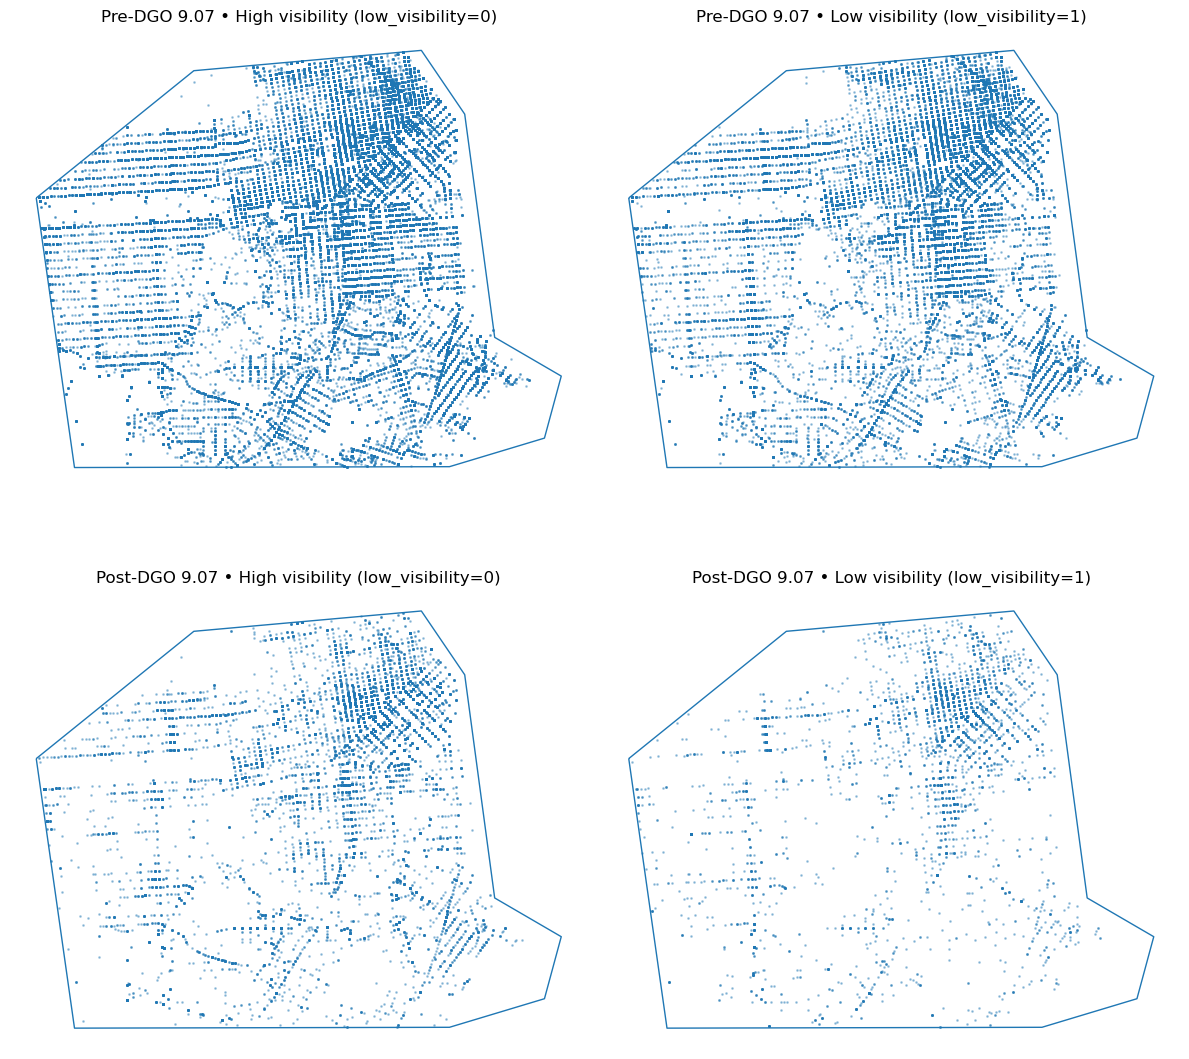

In [2]:
df["stop_datetime"] = pd.to_datetime(df["stop_datetime"], errors="coerce")
df = df.dropna(subset=["longitude", "latitude", "post_DGO", "low_visibility"])

# Geo
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

sf = gpd.read_file("https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_20m.zip")
sf = sf[sf["GEOID"] == "06075"]

gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")

# Subsets
pre_day   = gdf[(gdf["post_DGO"] == 0) & (gdf["low_visibility"] == 0)]
pre_low   = gdf[(gdf["post_DGO"] == 0) & (gdf["low_visibility"] == 1)]
post_day  = gdf[(gdf["post_DGO"] == 1) & (gdf["low_visibility"] == 0)]
post_low  = gdf[(gdf["post_DGO"] == 1) & (gdf["low_visibility"] == 1)]

# --- 2x2 comparison map: visibility × policy period ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

panels = [
    (pre_day,  axes[0, 0], "Pre-DGO 9.07 • High visibility (low_visibility=0)"),
    (pre_low,  axes[0, 1], "Pre-DGO 9.07 • Low visibility (low_visibility=1)"),
    (post_day, axes[1, 0], "Post-DGO 9.07 • High visibility (low_visibility=0)"),
    (post_low, axes[1, 1], "Post-DGO 9.07 • Low visibility (low_visibility=1)"),
]

for data, ax, title in panels:
    sf.boundary.plot(ax=ax, linewidth=1)
    ax.scatter(
        data.geometry.x,
        data.geometry.y,
        s=1,
        alpha=0.35
    )
    ax.set_title(title)
    ax.set_axis_off()

plt.tight_layout()
plt.savefig(
    "/Users/thisisjasmine/Desktop/ECO225/dgo907_visibility_comparison_2x2.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

/var/folders/jy/pc_qtmgx7vg538t3wpxxq4n00000gn/T/ipykernel_46499/2595322112.py:25: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")


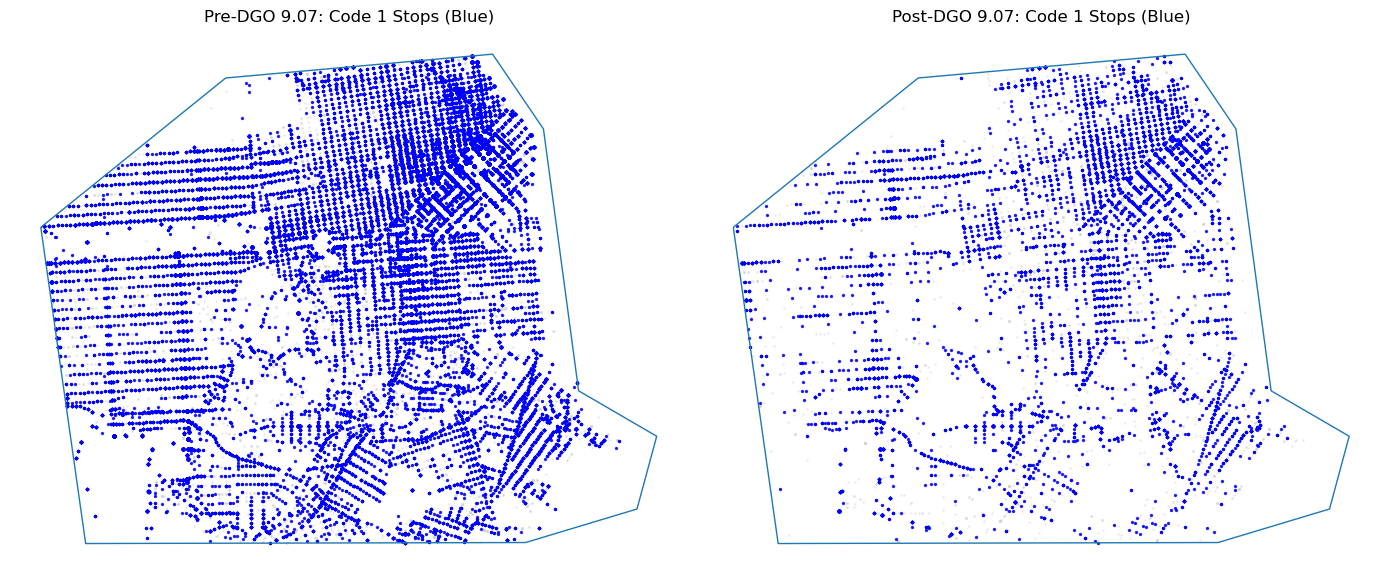

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

df = df.dropna(subset=["longitude", "latitude", "post_DGO", "reason_for_stop_code"])

df["reason_for_stop_code"] = pd.to_numeric(df["reason_for_stop_code"], errors="coerce")

# 如果看 Code 1
df["code1"] = (df["reason_for_stop_code"] == 1).astype(int)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

sf = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2018/shp/cb_2018_us_county_20m.zip"
)
sf = sf[sf["GEOID"] == "06075"]

gdf = gpd.sjoin(gdf, sf[["geometry"]], predicate="within", how="inner")

gdf_pre  = gdf[gdf["post_DGO"] == 0]
gdf_post = gdf[gdf["post_DGO"] == 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ---- Pre-DGO ----
sf.boundary.plot(ax=axes[0], linewidth=1)

axes[0].scatter(
    gdf_pre[gdf_pre["code1"] == 0].geometry.x,
    gdf_pre[gdf_pre["code1"] == 0].geometry.y,
    color="lightgrey",
    s=1,
    alpha=0.3
)

axes[0].scatter(
    gdf_pre[gdf_pre["code1"] == 1].geometry.x,
    gdf_pre[gdf_pre["code1"] == 1].geometry.y,
    color="blue",
    s=2,
    alpha=0.8
)

axes[0].set_title("Pre-DGO 9.07: Code 1 Stops (Blue)")
axes[0].set_axis_off()

# ---- Post-DGO ----
sf.boundary.plot(ax=axes[1], linewidth=1)

axes[1].scatter(
    gdf_post[gdf_post["code1"] == 0].geometry.x,
    gdf_post[gdf_post["code1"] == 0].geometry.y,
    color="lightgrey",
    s=1,
    alpha=0.3
)

axes[1].scatter(
    gdf_post[gdf_post["code1"] == 1].geometry.x,
    gdf_post[gdf_post["code1"] == 1].geometry.y,
    color="blue",
    s=2,
    alpha=0.8
)

axes[1].set_title("Post-DGO 9.07: Code 1 Stops (Blue)")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(
    "/Users/thisisjasmine/Desktop/ECO225/dgo907_code12_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
df["reason_for_stop_code"].value_counts(normalize=True)

reason_for_stop_code
1.0     0.605601
2.0     0.333752
4.0     0.027259
9.0     0.009658
6.0     0.008902
3.0     0.006165
5.0     0.005133
10.0    0.003494
8.0     0.000020
7.0     0.000015
Name: proportion, dtype: float64

<Axes: >

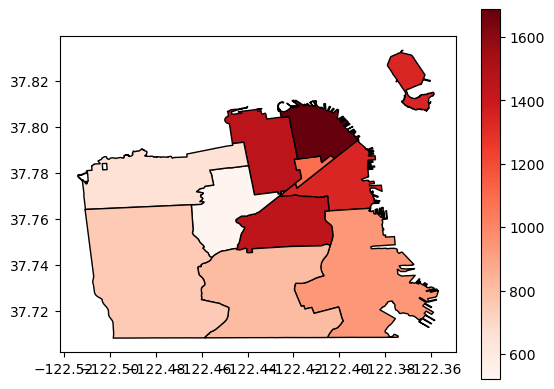

In [20]:
import pandas as pd
import geopandas as gpd
from shapely import wkt

# -------------------------
# 1. load main stop dataset
# -------------------------
df = pd.read_csv("/Users/thisisjasmine/Desktop/ECO225/cleaned_sfpd_data.csv")

df["stop_datetime"] = pd.to_datetime(df["stop_datetime"], errors="coerce")
df["year"] = df["stop_datetime"].dt.year
df["month"] = df["stop_datetime"].dt.month

# -------------------------
# 2. load crime dataset
# -------------------------
crime = pd.read_csv("/Users/thisisjasmine/Desktop/Crime_Rate_Dataset_with_month.csv")

crime["Incident Datetime"] = pd.to_datetime(crime["Incident Datetime"], errors="coerce")
crime["year"] = crime["Incident Datetime"].dt.year
crime["month"] = crime["Incident Datetime"].dt.month

crime_month = (
    crime.groupby(["Police District","year","month"])
    .size()
    .reset_index(name="crime_count")
)

# -------------------------
# 3. standardize district names
# -------------------------
df["district"] = df["district"].str.upper()
crime_month["Police District"] = crime_month["Police District"].str.upper()

# -------------------------
# 4. merge crime → stop data
# -------------------------
df_map = df.merge(
    crime_month,
    left_on=["district","year","month"],
    right_on=["Police District","year","month"],
    how="left"
)

# -------------------------
# 5. create district map data
# -------------------------
map_data = (
    df_map.groupby("district")
    .agg(
        search_rate=("searched","mean"),
        crime_rate=("crime_count","mean")
    )
    .reset_index()
)

# -------------------------
# 6. load police district boundary
# -------------------------
districts = pd.read_csv("/Users/thisisjasmine/Desktop/Current_Police_Districts.csv")

districts["geometry"] = districts["the_geom"].apply(wkt.loads)
districts = gpd.GeoDataFrame(districts, geometry="geometry")

districts["district"] = districts["district"].str.upper()

# -------------------------
# 7. merge map data
# -------------------------
map_df = districts.merge(map_data, on="district", how="left")

# -------------------------
# 8. plot map
# -------------------------
map_df.plot(
    column="crime_rate",
    cmap="Reds",
    legend=True,
    edgecolor="black"
)

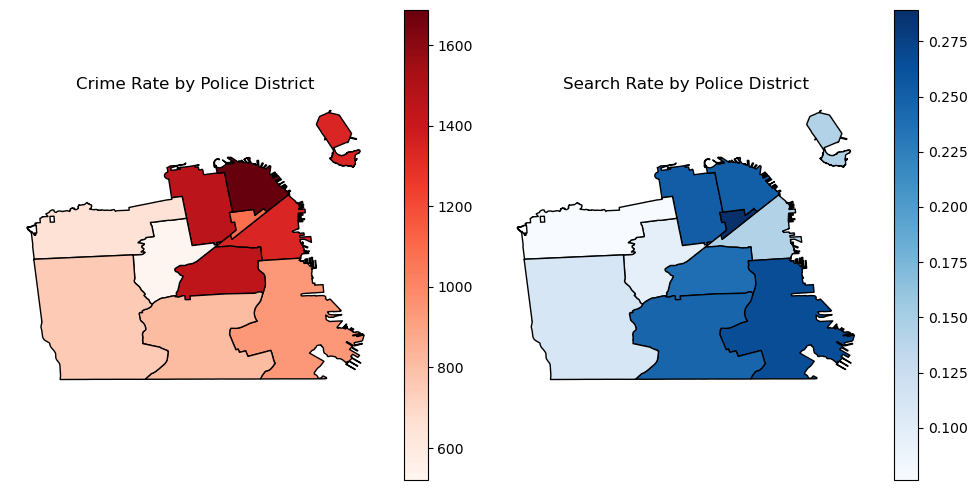

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Map 1: Crime rate
map_df.plot(
    column="crime_rate",
    cmap="Reds",
    legend=True,
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Crime Rate by Police District")
axes[0].set_axis_off()

# Map 2: Search rate
map_df.plot(
    column="search_rate",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=axes[1]
)
axes[1].set_title("Search Rate by Police District")
axes[1].set_axis_off()

plt.tight_layout()
plt.savefig(
    "/Users/thisisjasmine/Desktop/Crime Rate&Search Rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()